In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("BUYBACK DATASET.xlsx")

In [3]:
df

,timestamp,season,cloud_cover,day_type,hour,solar_generation_kWh,net_energy_kWh,battery_capacity_kWh,battery_level_kWh,buyback_demand_kWh,buyback_price
0,2024-01-01 00:00:00,Winter,48,Weekday,0,0.0,0.0,20,6,13.2,2.250808
1,2024-01-01 01:00:00,Winter,41,Weekday,1,0.0,0.0,20,6,13.2,1.991496
2,2024-01-01 02:00:00,Winter,40,Weekday,2,0.0,0.0,20,6,13.2,1.879960
3,2024-01-01 03:00:00,Winter,40,Weekday,3,0.0,0.0,20,6,13.2,1.939920
4,2024-01-01 04:00:00,Winter,43,Weekday,4,0.0,0.0,20,6,13.2,1.957984
...,...,...,...,...,...,...,...,...,...,...,...
17539,2025-12-31 19:00:00,Winter,87,Weekday,19,0.0,0.0,20,10,12.0,6.091128
17540,2025-12-31 20:00:00,Winter,72,Weekday,20,0.0,0.0,20,10,12.0,3.581824
17541,2025-12-31 21:00:00,Winter,53,Weekday,21,0.0,0.0,20,10,12.0,3.283048
17542,2025-12-31 22:00:00,Winter,46,Weekday,22,0.0,0.0,20,10,12.0,2.990392


In [4]:
df['buyback_price'].describe()

count    17544.000000
mean         3.431701
std          2.082237
min          0.049560
25%          2.156738
50%          2.743976
75%          3.802092
max          8.000000
Name: buyback_price, dtype: float64

In [5]:
df_1 = df.copy()

In [6]:
df['season'].unique()

array(['Winter', 'Summer', 'Monsoon'], dtype=object)

In [7]:
df['day_type'].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [8]:
df_1

,timestamp,season,cloud_cover,day_type,hour,solar_generation_kWh,net_energy_kWh,battery_capacity_kWh,battery_level_kWh,buyback_demand_kWh,buyback_price
0,2024-01-01 00:00:00,Winter,48,Weekday,0,0.0,0.0,20,6,13.2,2.250808
1,2024-01-01 01:00:00,Winter,41,Weekday,1,0.0,0.0,20,6,13.2,1.991496
2,2024-01-01 02:00:00,Winter,40,Weekday,2,0.0,0.0,20,6,13.2,1.879960
3,2024-01-01 03:00:00,Winter,40,Weekday,3,0.0,0.0,20,6,13.2,1.939920
4,2024-01-01 04:00:00,Winter,43,Weekday,4,0.0,0.0,20,6,13.2,1.957984
...,...,...,...,...,...,...,...,...,...,...,...
17539,2025-12-31 19:00:00,Winter,87,Weekday,19,0.0,0.0,20,10,12.0,6.091128
17540,2025-12-31 20:00:00,Winter,72,Weekday,20,0.0,0.0,20,10,12.0,3.581824
17541,2025-12-31 21:00:00,Winter,53,Weekday,21,0.0,0.0,20,10,12.0,3.283048
17542,2025-12-31 22:00:00,Winter,46,Weekday,22,0.0,0.0,20,10,12.0,2.990392


In [9]:
# Convert timestamp
df_1['timestamp'] = pd.to_datetime(df_1['timestamp'])
df_1 = df.sort_values(by='timestamp')

#  Encode season
season_map = {'Winter': 0, 'Summer': 1, 'Monsoon': 2}
df_1['season'] = df_1['season'].map(season_map)

#  Encode day_type
day_map = {'Weekday': 0, 'Weekend': 1}
df_1['day_type'] = df_1['day_type'].map(day_map)

In [10]:
features = ['season', 'hour', 'day_type', 'buyback_demand_kWh']
target = 'buyback_price'

X = df_1[features]
y = df_1[target]

In [11]:
train = df_1[df_1['timestamp'].dt.year == 2025]

In [12]:
future_dates = pd.date_range(start='2026-01-01', end='2026-01-07 23:00', freq='H')

future_df = pd.DataFrame({'timestamp': future_dates})

# Hour
future_df['hour'] = future_df['timestamp'].dt.hour

# Day type
future_df['day_type'] = future_df['timestamp'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# Season (Jan → Winter)
future_df['season'] = 0

# Grid demand (simple assumption → use last known pattern)
future_df['buyback_demand_kWh'] = df_1['buyback_demand_kWh'].tail(len(future_df)).values

C:\Users\akar7\AppData\Local\Temp\ipykernel_20580\1424261213.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start='2026-01-01', end='2026-01-07 23:00', freq='H')


In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

X_train = train[features]
y_train = train[target]

model_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,24)
)

model_fit = model_sarimax.fit()

forecast_sarimax = model_fit.forecast(
    steps=len(future_df),
    exog=future_df[features]
)

C:\Users\akar7\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\akar7\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\akar7\anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\akar7\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `star

In [14]:
future_df['SARIMAX'] = forecast_sarimax.values[:len(future_df)]

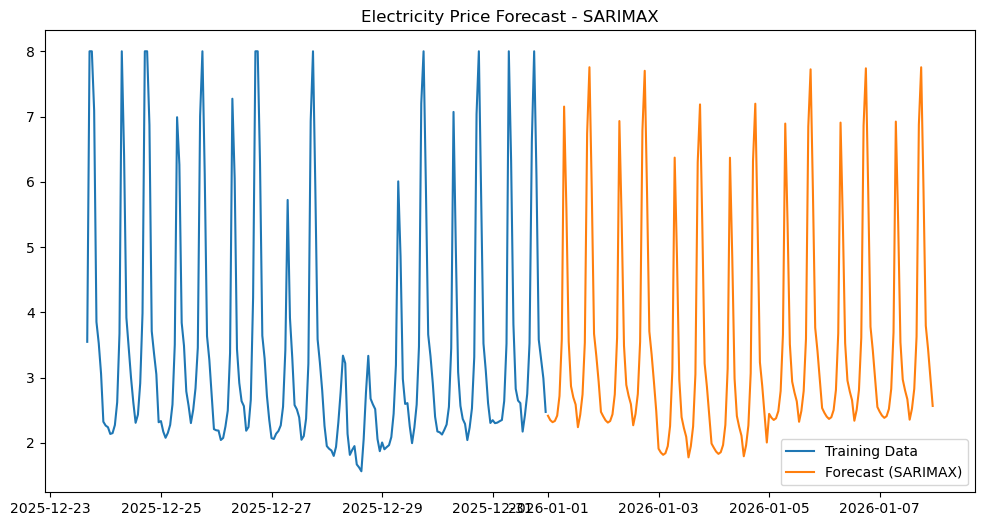

In [15]:
# Last part of training data (for visualization)
train_plot = train.set_index('timestamp')[target].iloc[-200:]

# Create future datetime index
future_index = future_df['timestamp']

# -----------------------------
#  2. SARIMAX Plot
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(train_plot, label="Training Data")
plt.plot(future_index, future_df['SARIMAX'], label="Forecast (SARIMAX)")

plt.title("Electricity Price Forecast - SARIMAX")
plt.legend()
plt.show()

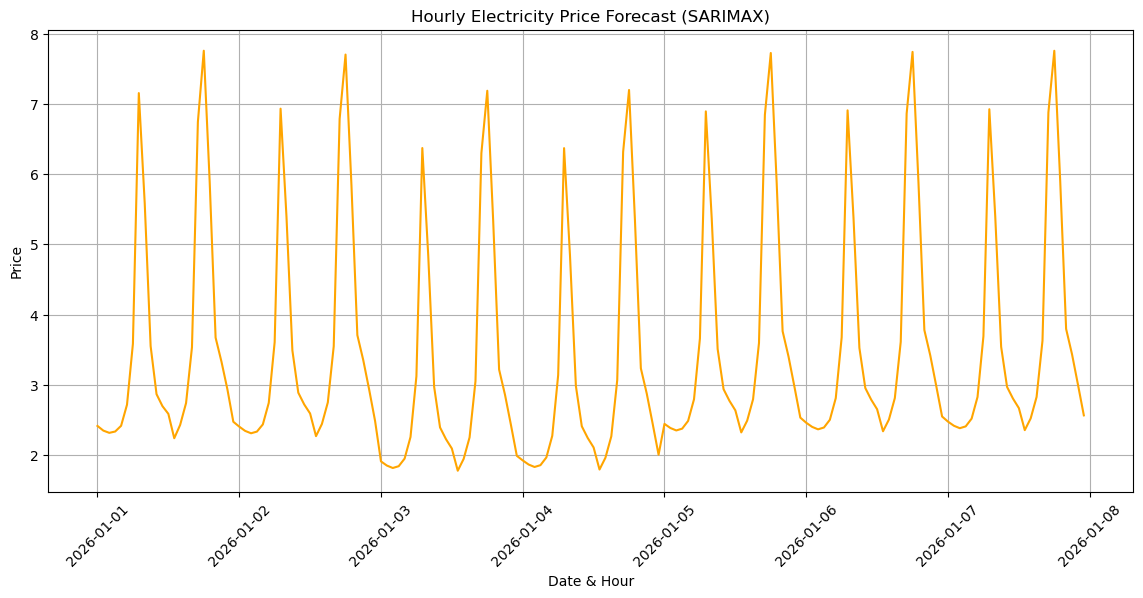

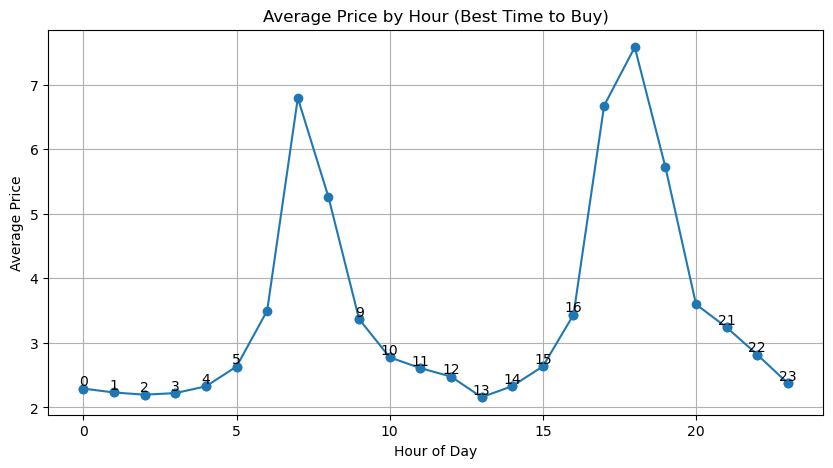

BEST HOURS TO BUY (Lowest Prices):
hour
13    2.157983
2     2.197373
3     2.221920
1     2.231549
0     2.291715
Name: SARIMAX, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# Combine forecast with time info
# -----------------------------
forecast_df = future_df.copy()
forecast_df['hour'] = forecast_df['timestamp'].dt.hour
forecast_df['date'] = forecast_df['timestamp'].dt.date

# -----------------------------
# 1. Plot Hourly Forecast (Better View)
# -----------------------------
plt.figure(figsize=(14,6))

plt.plot(forecast_df['timestamp'], forecast_df['SARIMAX'], color='orange')

plt.title("Hourly Electricity Price Forecast (SARIMAX)")
plt.xlabel("Date & Hour")
plt.ylabel("Price")

# Rotate for readability
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

# -----------------------------
# 2. Average Price by Hour (KEY INSIGHT)
# -----------------------------
hourly_avg = forecast_df.groupby('hour')['SARIMAX'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')

plt.title("Average Price by Hour (Best Time to Buy)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price")
plt.grid(True)

# Highlight cheapest hours
low_threshold = hourly_avg.mean()
low_hours = hourly_avg[hourly_avg < low_threshold]

plt.scatter(low_hours.index, low_hours.values)

for h in low_hours.index:
    plt.text(h, low_hours[h], f"{h}", ha='center', va='bottom')

plt.show()

# -----------------------------
# 3. Show BEST HOURS TO BUY
# -----------------------------
best_hours = hourly_avg.nsmallest(5)

print("BEST HOURS TO BUY (Lowest Prices):")
print(best_hours)

In [17]:
def create_future_dataframe(start_date, end_date, df):

    future_dates = pd.date_range(start=start_date, end=end_date, freq='H')

    future_df = pd.DataFrame({'timestamp': future_dates})

    # Hour
    future_df['hour'] = future_df['timestamp'].dt.hour

    # Day type (Weekend = 1)
    future_df['day_type'] = future_df['timestamp'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

    # Season (simple logic)
    def get_season(month):
        if month in [12,1,2]:
            return 0
        elif month in [3,4,5]:
            return 1
        elif month in [6,7,8,9,10,11]:
            return 2
        else:
            return 3

    future_df['season'] = future_df['timestamp'].dt.month.apply(get_season)

    # Demand → reuse past pattern
    future_df['buyback_demand_kWh'] = df['buyback_demand_kWh'].tail(len(future_df)).values

    return future_df

In [18]:
future_df = create_future_dataframe(
    start_date='2026-03-01 00:00',
    end_date='2026-03-07 23:00',
    df=df_1
)

C:\Users\akar7\AppData\Local\Temp\ipykernel_20580\3376832798.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start=start_date, end=end_date, freq='H')


In [19]:
forecast = model_fit.forecast(
    steps=len(future_df),
    exog=future_df[features]
)

future_df['Forecast_Price'] = forecast.values

C:\Users\akar7\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\akar7\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


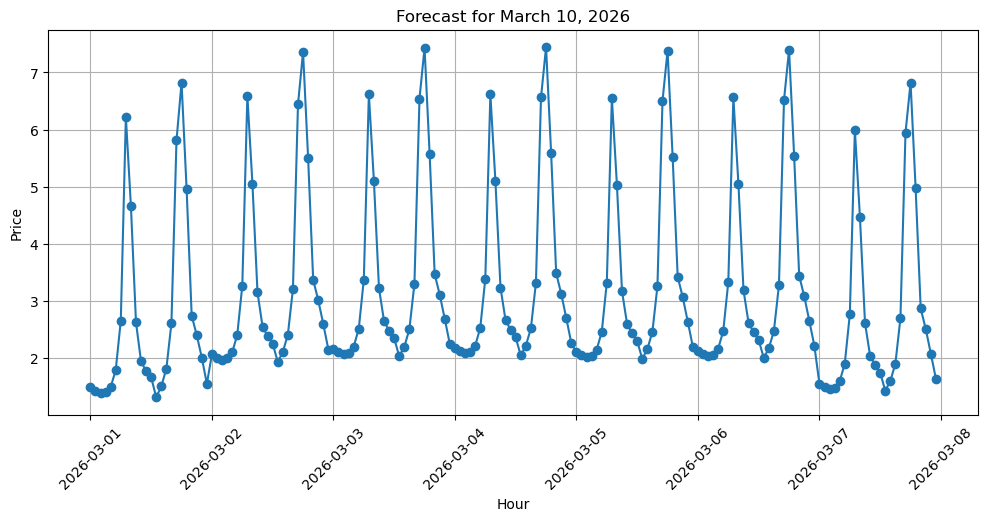

In [20]:
plt.figure(figsize=(12,5))

plt.plot(future_df['timestamp'], future_df['Forecast_Price'], marker='o')

plt.title("Forecast for March 10, 2026")
plt.xlabel("Hour")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [21]:
future_df['Forecast_Price'].describe()

count    168.000000
mean       3.124802
std        1.638625
min        1.308141
25%        2.062785
50%        2.482354
75%        3.340770
max        7.442220
Name: Forecast_Price, dtype: float64

In [22]:
high_threshold = future_df['Forecast_Price'].quantile(0.75)
medium_threshold = future_df['Forecast_Price'].quantile(0.50)

In [23]:
def buyback_decision(price):
    if price >= high_threshold:
        return "BATTERY"          # very expensive → use battery
    elif price >= medium_threshold:
        return "BATTERY_PARTIAL"  # medium → partial battery usage
    else:
        return "GRID"             # cheap → use grid

In [24]:
future_df["Forecast_Decision"] = future_df["Forecast_Price"].apply(buyback_decision)

In [25]:
future_df['Date'] = future_df['timestamp'].dt.date
future_df['Hour_Time'] = future_df['timestamp'].dt.strftime('%I %p').str.lstrip('0')

In [26]:
result = future_df[['Date', 'Hour_Time', 'Forecast_Price', 'Forecast_Decision']]
print(result.to_string())

           Date Hour_Time  Forecast_Price Forecast_Decision
0    2026-03-01     12 AM        1.483135              GRID
1    2026-03-01      1 AM        1.416325              GRID
2    2026-03-01      2 AM        1.384831              GRID
3    2026-03-01      3 AM        1.403697              GRID
4    2026-03-01      4 AM        1.485113              GRID
5    2026-03-01      5 AM        1.785610              GRID
6    2026-03-01      6 AM        2.651995   BATTERY_PARTIAL
7    2026-03-01      7 AM        6.219858           BATTERY
8    2026-03-01      8 AM        4.652607           BATTERY
9    2026-03-01      9 AM        2.619542   BATTERY_PARTIAL
10   2026-03-01     10 AM        1.935151              GRID
11   2026-03-01     11 AM        1.765071              GRID
12   2026-03-01     12 PM        1.655034              GRID
13   2026-03-01      1 PM        1.308141              GRID
14   2026-03-01      2 PM        1.498300              GRID
15   2026-03-01      3 PM        1.80910